# **Exploratory Data Analysis of Welltory COVID-19 Data & Research**

## **Understanding of Data**

**Meaning of featues:**
**Data collected includes:**

- **Heart rate variability measurements.** Measurements were made with any Bluetooth-enabled heart rate monitor or with a smartphone camera with a high resolution - a method called Photoplethysmography (PPG)

- Data from **user-connected gadgets** including devices such as Apple Watch and Garmin that sync with Google Fit or Apple Health.


- **Clinically validated physical and mental health assessments.*** We created a feature specifically for this project, where people would add information about symptoms and test results.


**Data context:**
The open COVID-19 research was carried out in **2020** year by the **Welltory** team to detect patterns regarding the COVID-19 disease; progression and recovery. As part of the research, Welltory users with positive COVID-19 status tracked their **symptoms, heart rate variability, and data** with the Welltory app. The research is open-research on a non-commerical basis.


- Data collected from wearable devices, surveys, and weather sources during COVID-19.
- Participants: ~28 unique users, but uneven participation
- Sampling: not uniform; some users have significantly more data and others have less data entries.




## **Questions we are asking**


What is the data structure/the dimensions of the dataset (number of rows and columns)?


What are the variable relationships/what are the data types of the variables (numerical, categorical, text, etc.)?


How is the data quality/are there any missing values, and if so, how are they represented?



### **Interpretation of data structure** 

Descriptive statistics, data quality, and variable relationships

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [6]:
# Load datasets:

blood_pressure = pd.read_csv("../data/blood_pressure.csv")
heart_rate = pd.read_csv("../data/heart_rate.csv")
hrv = pd.read_csv("../data/hrv_measurements.csv")
participants = pd.read_csv("../data/participants.csv")
scales = pd.read_csv("../data/scales_description.csv")
sleep = pd.read_csv("../data/sleep.csv")
surveys = pd.read_csv("../data/surveys.csv")
wearables = pd.read_csv("../data/wearables.csv")
weather = pd.read_csv("../data/weather.csv")


# create a dictionary of datasets to access easily
datasets = {
    "blood_pressure": blood_pressure,
    "heart_rate": heart_rate,
    "hrv": hrv,
    "participants": participants,
    "scales": scales,
    "sleep": sleep,
    "surveys": surveys,
    "wearables": wearables,
    "weather": weather
}

## **Understand data strcuture**
Look at the first few rows, column names, and data types to understand what each dataset contains.


In [11]:
# get quick info on datasets

for name, df in datasets.items():
    print(f"Dataset: {name}")
    print(df.info())
    print(df.describe(include='all'))
    print("\n\n")

Dataset: blood_pressure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 721 entries, 0 to 720
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_code                 721 non-null    object 
 1   measurement_datetime      721 non-null    object 
 2   diastolic                 721 non-null    int64  
 3   systolic                  721 non-null    int64  
 4   functional_changes_index  299 non-null    float64
 5   circulatory_efficiency    299 non-null    float64
 6   kerdo_vegetation_index    283 non-null    float64
 7   robinson_index            299 non-null    float64
dtypes: float64(4), int64(2), object(2)
memory usage: 45.2+ KB
None
         user_code  measurement_datetime   diastolic    systolic  \
count          721                   721  721.000000  721.000000   
unique          28                   719         NaN         NaN   
top     a1c2e6b2eb  2020-05-11  00:27:56         N

**Takeaways from Blood pressure dataset:**

- Blood pressure columns (systolic/diastolic) are complete.

- Most of the calculated indices are missing for >50% of rows.

In [15]:
# Summarize each dataset 

def summarize_dataset(name, df):
    print(f"\n {name.upper()}")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    
    print("Columns:", list(df.columns))
    
    # Find missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100 # Used claude sonnet 4 at 1:34pm on 9/16/2025 to help with this code line
    print("\nMissing Values:")
    print(pd.DataFrame({"count": missing, "percent": missing_pct }).sort_values(by="percent", ascending=False)) # Used claude sonnet 4 at 1:35pm on 9/16/2025 to help with sorting the values to make data easier to understand 
    
   
    if df.select_dtypes(include=[np.number]).shape[1] > 0: 
        print("\nNumeric Summary:")
        display(df.describe().transpose()[["mean","min","max"]]) # shows mean, min, max for numeric columns to understand distribution of important features
        # Used claude sonnet 4 at 1:38pm on 9/16/2025 to help with this code block to show mean, min, max for numeric columns to understand distribution of important features
    
    # Quick stats for categorical/object columns
    if df.select_dtypes(include=["object"]).shape[1] > 0: # Used claude sonnet 4 at 1:40pm on 9/16/2025 to help with this code block for categorical columns
        print("\nCategorical Summary:") 
        for col in df.select_dtypes(include=["object"]).columns:
            unique_vals = df[col].nunique() 
            most_common = df[col].mode()[0] if not df[col].mode().empty else None # Shows most common value in categorical columns (helps to understand distribution)
            print(f"- {col}: {unique_vals} unique, most common = {most_common}") # Used claude sonnet 4 at 1:42pm on 9/16/2025 to help with this code line to descibe findings from code in readable way

    print("\n" + "-"*50)  # Used claude sonnet 4 at 1:43pm on 9/16/2025 to help with this code line to separate findings for each dataset to make it easier to follow

# Run summary for all datasets
for name, df in datasets.items():
    summarize_dataset(name, df)



 BLOOD_PRESSURE
Shape: 721 rows, 8 columns
Columns: ['user_code', 'measurement_datetime', 'diastolic', 'systolic', 'functional_changes_index', 'circulatory_efficiency', 'kerdo_vegetation_index', 'robinson_index']

Missing Values:
                          count   percent
kerdo_vegetation_index      438  60.74896
functional_changes_index    422  58.52982
circulatory_efficiency      422  58.52982
robinson_index              422  58.52982
user_code                     0   0.00000
measurement_datetime          0   0.00000
diastolic                     0   0.00000
systolic                      0   0.00000

Numeric Summary:


,mean,min,max
diastolic,81.228849,25.00,101.00
systolic,119.441054,63.00,157.00
functional_changes_index,2.594013,1.68,3.51
circulatory_efficiency,2735.197057,1300.00,7875.00
kerdo_vegetation_index,-15.498233,-76.00,45.00
robinson_index,84.663779,49.50,164.85



Categorical Summary:
- user_code: 28 unique, most common = a1c2e6b2eb
- measurement_datetime: 719 unique, most common = 2020-05-10  21:27:56

--------------------------------------------------

 HEART_RATE
Shape: 523783 rows, 4 columns
Columns: ['user_code', 'datetime', 'heart_rate', 'is_resting']

Missing Values:
            count  percent
user_code       0      0.0
datetime        0      0.0
heart_rate      0      0.0
is_resting      0      0.0

Numeric Summary:


,mean,min,max
heart_rate,90.856626,10.0,232.0
is_resting,0.005546,0.0,1.0



Categorical Summary:
- user_code: 79 unique, most common = 35c7355282
- datetime: 506422 unique, most common = 2020-02-18 19:13:39

--------------------------------------------------

 HRV
Shape: 3245 rows, 22 columns
Columns: ['user_code', 'rr_code', 'measurement_datetime', 'time_of_day', 'bpm', 'meanrr', 'mxdmn', 'sdnn', 'rmssd', 'pnn50', 'mode', 'amo', 'lf', 'hf', 'vlf', 'lfhf', 'total_power', 'how_feel', 'how_mood', 'how_sleep', 'tags', 'rr_data']

Missing Values:
                      count    percent
how_sleep              1779  54.822804
tags                   1044  32.172573
user_code                 0   0.000000
rr_code                   0   0.000000
how_mood                  0   0.000000
how_feel                  0   0.000000
total_power               0   0.000000
lfhf                      0   0.000000
vlf                       0   0.000000
hf                        0   0.000000
lf                        0   0.000000
amo                       0   0.000000
mode               

...


Categorical Summary:
- user_code: 111 unique, most common = 6be5033971
- scale: 58 unique, most common = S_COVID_FATIGUE
- created_at: 50 unique, most common = 2020-05-03
- text: 65 unique, most common = User isn’t experiencing symptom

--------------------------------------------------

 WEARABLES
Shape: 3098 rows, 18 columns
Columns: ['user_code', 'day', 'resting_pulse', 'pulse_average', 'pulse_min', 'pulse_max', 'average_spo2_value', 'body_temperature_avg', 'stand_hours_total', 'steps_count', 'distance', 'steps_speed', 'total_number_of_flights_climbed', 'active_calories_burned', 'basal_calories_burned', 'total_calories_burned', 'average_headphone_exposure', 'average_environment_exposure']

Missing Values:
                                 count    percent
average_spo2_value                3058  98.708844
body_temperature_avg              3033  97.901872
average_environment_exposure      2949  95.190445
average_headphone_exposure        2868  92.575855
stand_hours_total              

,mean,min,max
resting_pulse,61.409241,40.00,109.00
pulse_average,78.084251,48.00,163.00
pulse_min,63.078506,10.00,122.00
pulse_max,99.456199,48.00,225.00
average_spo2_value,0.961000,0.92,0.99
body_temperature_avg,36.404615,35.80,36.90
stand_hours_total,8.986817,1.00,19.00
steps_count,5342.067581,1.00,30882.00
distance,3494.690744,1.00,43914.00
steps_speed,29.700409,0.01,240.00



Categorical Summary:
- user_code: 79 unique, most common = 0d297d2410
- day: 171 unique, most common = 2020-05-03

--------------------------------------------------

 WEATHER
Shape: 1717 rows, 7 columns
Columns: ['user_code', 'day', 'avg_temperature_C', 'atmospheric_pressure', 'precip_intensity', 'humidity', 'clouds']

Missing Values:
                      count  percent
user_code                 0      0.0
day                       0      0.0
avg_temperature_C         0      0.0
atmospheric_pressure      0      0.0
precip_intensity          0      0.0
humidity                  0      0.0
clouds                    0      0.0

Numeric Summary:


,mean,min,max
avg_temperature_C,11.839221,-13.15,44.0722
atmospheric_pressure,1014.111639,984.30,1047.7500
precip_intensity,0.003803,0.00,0.2567
humidity,66.376586,3.00,100.0000
clouds,56.401734,0.00,100.0000



Categorical Summary:
- user_code: 104 unique, most common = 295ed96279
- day: 169 unique, most common = 2020-05-06

--------------------------------------------------


## Variable Relationships

Eplore relationships between variables across datasets to get better undestanding of which features are worth feature engineerng. 

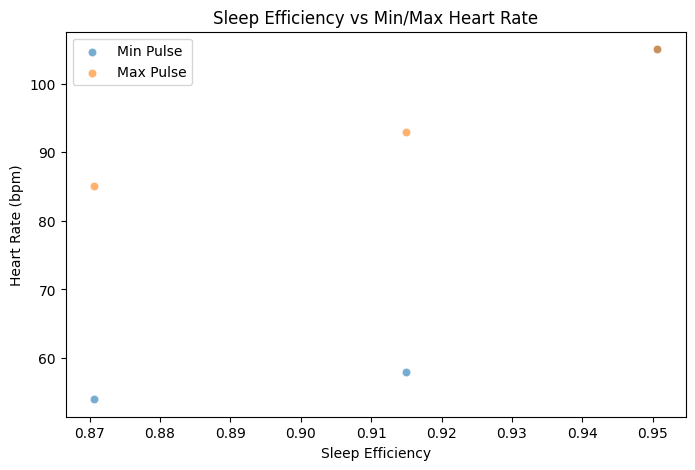

In [ ]:
# Make sure sleep efficiency exists
sleep["sleep_efficiency"] = sleep["sleep_duration"] / (
    sleep["sleep_duration"] + sleep["sleep_awake_duration"] # time awake during the sleep period. Used claude at 2:00pm on 9/16/2025 to help with this code line
)

# Plot sleep efficiency vs average nightly pulse
plt.figure(figsize=(8,5))
sns.scatterplot(data=sleep, x="sleep_efficiency", y="pulse_min", alpha=0.6, label="Min Pulse") # used claude sonnet 4 at 2:05pm on 9/16/2025 to help with this code line to add alpha and label
sns.scatterplot(data=sleep, x="sleep_efficiency", y="pulse_max", alpha=0.6, label="Max Pulse") # used claude sonnet 4 at 2:05pm on 9/16/2025 to help with this code line to add alpha and label
plt.xlabel("Sleep Efficiency")
plt.ylabel("Heart Rate (bpm)")
plt.title("Sleep Efficiency vs Min/Max Heart Rate")
plt.legend()
plt.show()


### Sleep Efficiency vs Min/Max Heart Rate
Goal: to show the relationship between sleep efficiency and the  minimum and maximum heart rate of individual.

**Takeaways:**
- Most values cluster around high sleep efficiency (0.87–0.95) (i.e., lower values aren't documeted at all) 
- Minimum heart rate generally around 60–65 bpm, while maximum values can exceed 100 bpm.  
- The dataset has **very few points** with pulse data available, which makes it hard to draw strong conclusions.  


- Overall, the plot indicates that participants with higher sleep efficiency still experience a wide range of heart rates, showing that sleep efficiency and heart rate are related but not strongly correlated.  



**Rationale:**  
Sleep efficiency is an important measure of rest quality, and heart rate is a key measure tracked by wearables that Welltory used for  data collection. Looking at these variable together helps show whether more efficient sleep is associated with lower or more stable heart rates for COVID-19 patients



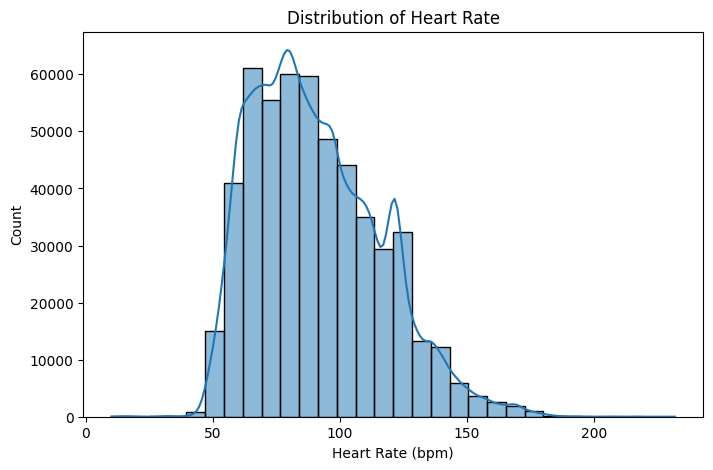

In [ ]:
# heart rate distribution

plt.figure(figsize=(8,5))
sns.histplot(heart_rate["heart_rate"], bins=30, kde=True) # Used claude sonnet 4 at 2:10pm on 9/16/2025 to help with this code line to add kde=True and bin size
plt.xlabel("Heart Rate (bpm)")
plt.title("Distribution of Heart Rate")
plt.show()


### Distribution of Heart Rate
The histogram shows the distribution of heart rate values across all participants.  
- Most heart rate values fall between 60–100 bpm, which is within the normal resting range according to health.harvard.edu
- A few higher values (above 150 bpm) exist, which may represent either physical activity or potential outliers.  
- The distribution is slightly right-skewed, with more data points at higher heart rates than at very low ones.  
 
 Overall, the data looks reasonable but may require specific data extraction due to the outliers to avoid bias. 


 **Rationale:**  
Understanding the overall distribution of heart rate is important to understand an individual's health and can be a strong indicator for for spotting unusual values since the normal/healthy BPM is widely undersdtood. This plot shows a check for data quality and helps ensure that wearable-collected data aligns with physiological health symptoms.  
  


## ** New Feature: Sleep-Adjusted Heart Rate**

**Goal:**
Flag whether a person’s average nightly heart rate is in a "healthy" range given how much they slept.

**Normal resting heart rate:** 60–100 bpm

**Adequate sleep duration:** ≥ 7 hours (commonly recommended)

**KEY:**

**"Good"** → HR between **60–100** and sleep duration **≥ 7 hours**

**"Poor"** → Other

/var/folders/56/f8hqccqd187g4n1hnvfd_fcr0000gn/T/ipykernel_81711/895722279.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sleep, x="sleep_hr_status", palette="Set2")


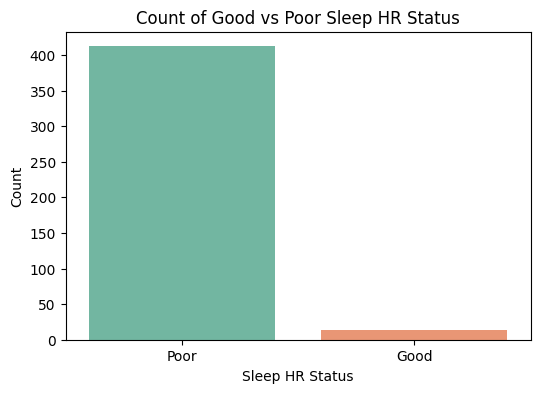

In [34]:
# sleep efficiency used from earlier cell
sleep["sleep_efficiency"] = sleep["sleep_duration"] / (
    sleep["sleep_duration"] + sleep["sleep_awake_duration"]
)

# "good" sleep HR status feature
def hr_sleep_status(row): # collects each row in the dataframe
    if 60 <= row["pulse_average"] <= 100 and row["sleep_duration"] >= 7:
        return "Good"
    else:
        return "Poor"

sleep["sleep_hr_status"] = sleep.apply(hr_sleep_status, axis=1) # axis of 1 to apply function to each row 

# Plot count of good vs poor sleep HR status
plt.figure(figsize=(6,4))
sns.countplot(data=sleep, x="sleep_hr_status", palette="Set2")
plt.title("Count of Good vs Poor Sleep HR Status")
plt.xlabel("Sleep HR Status")
plt.ylabel("Count")
plt.show()




### Good vs Poor Sleep HR Status by Participant
This plot shows the distribution of the new sleep_hr_status feature for each participant.  

**Takeaways:** 
- Most participants had a more  "Poor" nights compared to "Good" nights.  
- This indicates that few participants consistently met both criteria (sleep ≥ 7 hours and heart rate between 60–100 bpm).  